In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/nlu_assignment')

# Verify you're in the right place
print("Current directory:", os.getcwd())

print("\nFiles in this directory:")
!ls -la

Current directory: /content/drive/MyDrive/nlu_assignment

Files in this directory:
total 484
drwx------ 2 root root   4096 Jan 27 22:26 backups
drwx------ 2 root root   4096 Jan 27 00:33 checkpoints
drwx------ 2 root root   4096 Jan 26 20:51 dataset
drwx------ 2 root root   4096 Jan 26 20:51 evaluation
-rw------- 1 root root   6486 Jan 28 17:14 evaluation_peft_corrected.py
-rw------- 1 root root   7309 Jan 28 17:07 evaluation_peft.py
drwx------ 2 root root   4096 Jan 26 20:51 finetuning
drwx------ 2 root root   4096 Jan 26 20:51 grpo
drwx------ 2 root root   4096 Jan 26 21:51 outputs
-rw------- 1 root root    921 Jan 27 00:08 q3_3_training_sample.txt
-rw------- 1 root root   5017 Jan 26 20:49 README.md
-rw------- 1 root root     80 Feb 25 14:23 requirements.txt
-rw------- 1 root root 175424 Feb 25 15:41 sft_vs_grpo_comparison.png
-rw------- 1 root root 265405 Mar 11 17:31 sft_vs_grpo_with_tokens.png
drwx------ 2 root root   4096 Jan 27 00:33 wandb


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 56.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [ ]:
!nvidia-smi

Wed Feb 25 14:23:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import wandb
import os

# Set project name
MODEL_SIGNATURE = "Qwen/Qwen2.5-0.5B-Instruct"
os.environ["WANDB_PROJECT"] = "nlu-gsm8k-assignment"

# Login
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: ERROR Invalid API key: API key may only contain the letters A-Z, digits and underscores.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s2808241 (s2808241-university-of-ediburgh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Quick test to ensure everything works
from transformers import AutoTokenizer
import torch

print("✅ PyTorch version:", torch.__version__)
print("✅ CUDA available:", torch.cuda.is_available())
print("✅ GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

# Test loading tokenizer (quick)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
print("✅ Tokenizer loaded successfully")
print("\n🎉 Setup complete! Ready to start.")

✅ PyTorch version: 2.9.0+cu126
✅ CUDA available: True
✅ GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded successfully

🎉 Setup complete! Ready to start.


**Looking for Bug in Finetune.py file**

In [ ]:
print("=" * 80)
print("READING finetuning/main.py - Look for bugs!")
print("=" * 80)
!cat finetuning/main.py

READING finetuning/main.py - Look for bugs!
import re
import torch
from datasets import load_from_disk
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig
from trl import SFTTrainer
import wandb

from prompt import sft_formatting_prompts_func
from hyperparameter import get_training_arguments
import random
import numpy as np
import os
import torch
import argparse

def set_seed(seed=42):
    """Set seed for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

def main():

    set_seed(42)
    parser = argparse.ArgumentParser(description="Process datasets")
    parser.add_argument("--model_signature", default="HuggingFaceTB/SmolLM2-135M-Instruct", help="Huggingface model signature for training.")
    parser.add

In [ ]:
print("\n" + "=" * 80)
print("hyperparameter.py")
print("=" * 80)
!cat finetuning/hyperparameter.py

print("\n" + "=" * 80)
print("prompt.py")
print("=" * 80)
!cat finetuning/prompt.py


hyperparameter.py
from trl import SFTConfig

def get_training_arguments(output_model, learning_rate):
    return SFTConfig(
        output_dir=output_model,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=8,
        learning_rate=learning_rate,
        lr_scheduler_type="linear",
        num_train_epochs=2,
        max_steps=-1,
        gradient_checkpointing=True,
        warmup_steps=5,
        max_grad_norm=1.0,
        bf16=True,
        push_to_hub=False,     
        logging_steps=5,
        save_strategy="epoch",
        report_to="none",
        eval_strategy="steps",
        logging_strategy="steps",
        eval_steps=10,
        optim="adamw_torch_fused", 
        packing=False,
        dataset_text_field='text',
        seed=42,
    )

prompt.py
import re

def sft_formatting_prompts_func(tokenizer, example):
    q = example["question"].strip()
    raw_answer = example["answer"].strip()
    
    if "####" in raw_answer:
        reasoning, final_an

In [ ]:
# This takes 10-15 minutes - START IT NOW
MODEL_SIGNATURE = "Qwen/Qwen2.5-0.5B-Instruct"

!python evaluation/main.py \
    --model_signature $MODEL_SIGNATURE \
    --output_path ./outputs/$MODEL_SIGNATURE-zero-shot

2026-01-26 21:51:19.086603: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769464279.106070    2852 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769464279.112103    2852 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769464279.126921    2852 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769464279.126943    2852 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769464279.126947    2852 computation_placer.cc:177] computation placer alr

** Zero Shot Evaluation of Qwen2.5-0.5B**


In [ ]:
# Run this in a new cell while Instruct model runs
MODEL_SIGNATURE_BASE = "Qwen/Qwen2.5-0.5B"

!python evaluation/main.py \
    --model_signature $MODEL_SIGNATURE_BASE \
    --output_path ./outputs/$MODEL_SIGNATURE_BASE-zero-shot

2026-01-26 22:01:47.412124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769464907.431614    5576 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769464907.437482    5576 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769464907.452587    5576 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769464907.452612    5576 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769464907.452624    5576 computation_placer.cc:177] computation placer alr

In [ ]:
# After both finish, check results

print("=" * 80)
print("INSTRUCT MODEL (Zero-shot)")
print("=" * 80)
!cat ./outputs/Qwen/Qwen2.5-0.5B-Instruct-zero-shot/results.json


INSTRUCT MODEL (Zero-shot)
[
  {
    "question": "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?",
    "model_result": "To determine how much Janet makes at the farmers' market each day, we need to follow these steps:\n\n1. Calculate the total number of eggs laid by the ducks in a day.\n2. Subtract the number of eggs eaten in the morning from the total number of eggs laid.\n3. Subtract the number of eggs baked from the remaining eggs after breakfast.\n4. Multiply the remaining eggs by the price at which they are sold.\n\nLet's go through each step in detail:\n\n1. **Calculate the total number of eggs laid by the ducks in a day:**\n   - Janet has 16 ducks.\n   - Each duck lays 16 eggs per day.\n   \\[\n   \\text{Total eggs} = 16 \\times 16 = 256\n   \\]\n\n

In [ ]:

print("\n" + "=" * 80)
print("BASE MODEL (Zero-shot)")
print("=" * 80)
!cat ./outputs/Qwen/Qwen2.5-0.5B-zero-shot/results.json


BASE MODEL (Zero-shot)
[
  {
    "question": "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?",
    "model_result": "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market? Janet makes $16 x 16 = $256 in eggs every day. She eats 3 x 7 = 21 eggs every day. She sells 256 - 21 = 235 eggs every day. She makes 235 x 2 = $470 at the farmers' market every day.",
    "final_answer": "470",
    "correct_answer": "18",
    "is_correct": false
  },
  {
    "question": "A robe takes 2 bolts of blue fiber and half that much white fiber.  How many b

In [ ]:
# Quick check for Instruct model
!python -c "import json; r=json.load(open('./outputs/Qwen/Qwen2.5-0.5B-Instruct-zero-shot/results.json')); c=sum(1 for x in r if x['is_correct']); print(f'Instruct Accuracy: {c}/{len(r)} = {c/len(r)*100:.2f}%')"

# Quick check for Base model
!python -c "import json; r=json.load(open('./outputs/Qwen/Qwen2.5-0.5B-zero-shot/results.json')); c=sum(1 for x in r if x['is_correct']); print(f'Base Accuracy: {c}/{len(r)} = {c/len(r)*100:.2f}%')"

Instruct Accuracy: 14/100 = 14.00%
Base Accuracy: 12/100 = 12.00%


In [ ]:
# Look at the prompt template
print("=" * 80)
print("PROMPT TEMPLATE")
print("=" * 80)
!cat finetuning/prompt.py

PROMPT TEMPLATE
import re

def sft_formatting_prompts_func(tokenizer, example):
    q = example["question"].strip()
    raw_answer = example["answer"].strip()
    
    if "####" in raw_answer:
        reasoning, final_ans = raw_answer.split("####", 1)
        reasoning = reasoning.strip()
        final_ans = final_ans.strip()
    else:
        reasoning = raw_answer
        final_ans = ""

    formatted_answer = f"{reasoning}\n\nThe answer is {final_ans}"

    instruction = "Think step by step before answering the question, and provide the final answer as 'the answer is [answer]' format." 

    messages = [
        {"role": "system", "content": instruction},
        {"role": "user", "content": q},
        {"role": "assistant", "content": formatted_answer}
    ]

    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    formatted_text += tokenizer.eos_token
    
    return {"text": formatted_text}

In [ ]:
import os
os.chdir('/content/drive/MyDrive/nlu_assignment')

print("=" * 80)
print("READING prompt.py TO UNDERSTAND FORMAT")
print("=" * 80)

!cat finetuning/prompt.py

READING prompt.py TO UNDERSTAND FORMAT
import re

def sft_formatting_prompts_func(tokenizer, example):
    q = example["question"].strip()
    raw_answer = example["answer"].strip()
    
    if "####" in raw_answer:
        reasoning, final_ans = raw_answer.split("####", 1)
        reasoning = reasoning.strip()
        final_ans = final_ans.strip()
    else:
        reasoning = raw_answer
        final_ans = ""

    formatted_answer = f"{reasoning}\n\nThe answer is {final_ans}"

    instruction = "Think step by step before answering the question, and provide the final answer as 'the answer is [answer]' format." 

    messages = [
        {"role": "system", "content": instruction},
        {"role": "user", "content": q},
        {"role": "assistant", "content": formatted_answer}
    ]

    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    formatted_text += tokenizer.eos_token
    
    return {"text": 

** Question 3.3:  Manually Check One SFT Training Sample:**

In [ ]:
import os
import sys
from datasets import load_from_disk
from transformers import AutoTokenizer

os.chdir('/content/drive/MyDrive/nlu_assignment')
sys.path.append('./finetuning')

# Import the formatting function
from prompt import sft_formatting_prompts_func

print("=" * 80)
print("Q3.3: SFT TRAINING SAMPLE WITH SPECIAL TOKENS")
print("=" * 80)

# Load tokenizer
print("\n📥 Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

# Load training dataset
print("📥 Loading training dataset...")
ds = load_from_disk("dataset/gsm8k_3k_sft")

# Get the first training sample
sample = ds[0]

print("\n" + "=" * 80)
print("📋 RAW DATA (Before Formatting)")
print("=" * 80)
print("\n🔹 Question:")
print(sample['question'])
print("\n🔹 Answer:")
print(sample['answer'])

# Format it using the function
formatted_sample = sft_formatting_prompts_func(tokenizer, sample)

print("\n" + "=" * 80)
print("✅ FORMATTED TRAINING SAMPLE (COPY THIS FOR Q3.3)")
print("=" * 80)
print("\nThis is exactly what the model sees during training:")
print("\n" + "-" * 80)
print(formatted_sample['text'])
print("-" * 80)

print("\n" + "=" * 80)
print("💾 SAVING TO FILE")
print("=" * 80)

# Save to file
with open('q3_3_training_sample.txt', 'w', encoding='utf-8') as f:
    f.write("Q3.3: SFT Training Sample\n")
    f.write("=" * 80 + "\n\n")
    f.write("INSTRUCTIONS: Copy everything below (including special tokens)\n")
    f.write("=" * 80 + "\n\n")
    f.write(formatted_sample['text'])
    f.write("\n\n" + "=" * 80 + "\n")
    f.write("END OF SAMPLE\n")

print("✅ Sample saved to 'q3_3_training_sample.txt'")

# Download it
from google.colab import files
files.download('q3_3_training_sample.txt')

print("\n" + "=" * 80)
print("📝 FOR YOUR GRADESCOPE SUBMISSION:")
print("=" * 80)
print("Copy everything between the dashed lines above")
print("(including <|im_start|>, <|im_end|>, and <|endoftext|> tokens)")
print("=" * 80)

Q3.3: SFT TRAINING SAMPLE WITH SPECIAL TOKENS

📥 Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

📥 Loading training dataset...

📋 RAW DATA (Before Formatting)

🔹 Question:
Mimi picked up 2 dozen seashells on the beach.  Kyle found twice as many shells as Mimi and put them in his pocket. Leigh grabbed one-third of the shells that Kyle found.  How many seashells did Leigh have?

🔹 Answer:
Mimi has 2 x 12 = <<2*12=24>>24 sea shells.
Kyle has 24 x 2 = <<24*2=48>>48 sea shells.
Leigh has 48 / 3 = <<48/3=16>>16 sea shells.
#### 16

✅ FORMATTED TRAINING SAMPLE (COPY THIS FOR Q3.3)

This is exactly what the model sees during training:

--------------------------------------------------------------------------------
<|im_start|>system
Think step by step before answering the question, and provide the final answer as 'the answer is [answer]' format.<|im_end|>
<|im_start|>user
Mimi picked up 2 dozen seashells on the beach.  Kyle found twice as many shells as Mimi and put them in his pocket. Leigh grabbed one-third of the shells that Kyle found.  How many seashells did Leigh have?<|im_end|>
<|

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📝 FOR YOUR GRADESCOPE SUBMISSION:
Copy everything between the dashed lines above
(including <|im_start|>, <|im_end|>, and <|endoftext|> tokens)


In [ ]:
import os
import torch
import wandb

os.chdir('/content/drive/MyDrive/nlu_assignment')

print("=" * 80)
print("PRE-TRAINING CHECKLIST")
print("=" * 80)

# Check 1: GPU available
print("\n1. GPU Check:")
print(f"   ✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   ✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   ✓ Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   ❌ NO GPU - Go to Edit > Notebook Settings > Enable T4 GPU")

# Check 2: Bug fixed
print("\n2. Bug Fix Check:")
!grep -n "test_size" finetuning/main.py | head -1

# Check 3: WandB login
print("\n3. WandB Status:")
try:
    api = wandb.Api()
    user = api.viewer
    print(f"   ✓ Logged in as: {user.username}")
except:
    print("   ❌ Not logged in - run: wandb.login()")

# Check 4: Disk space
print("\n4. Disk Space:")
!df -h /content/drive/MyDrive | grep -v Filesystem

print("\n" + "=" * 80)
print("✅ Ready to start training!")
print("=" * 80)

PRE-TRAINING CHECKLIST

1. GPU Check:
   ✓ CUDA available: True
   ✓ GPU: Tesla T4
   ✓ Memory: 15.83 GB

2. Bug Fix Check:
72:    train_test = ds.train_test_split(test_size=0.1, train_size =0.9, seed=42)

3. WandB Status:


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


   ✓ Logged in as: s2808241

4. Disk Space:
drive            30G   17G   14G  56% /content/drive

✅ Ready to start training!


In [ ]:
import wandb

# If not logged in, login now
print("Getting your WandB API key...")
print("Go to: https://wandb.ai/authorize")
print("\nOr run this to login:")

wandb.login()

# Store your key for later use
import os
WANDB_API_KEY = os.environ.get('WANDB_API_KEY', 'YOUR_KEY_HERE')
print(f"\n✅ WandB ready!")

wandb: Currently logged in as: s2808241 (s2808241-university-of-ediburgh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Getting your WandB API key...
Go to: https://wandb.ai/authorize

Or run this to login:

✅ WandB ready!


In [ ]:
import os
os.chdir('/content/drive/MyDrive/nlu_assignment')

print("=" * 80)
print("REINSTALLING ALL REQUIREMENTS")
print("=" * 80)

# Reinstall from requirements.txt
!pip install -q --upgrade -r requirements.txt

# Verify key packages
print("\nVerifying installations:")
!pip list | grep -E "trl|peft|transformers|torch|datasets"

print("\n✅ Requirements reinstalled!")

REINSTALLING ALL REQUIREMENTS
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 20.2 MB/s eta 0:00:00

Verifying installations:
datasets                                 4.0.0
fastrlock                                0.8.3
peft                                     0.17.1
sentence-transformers                    5.2.0
tensorflow-datasets                      4.9.9
torch                                    2.9.0+cu126
torchao                                  0.10.0
torchaudio                               2.9.0+cu126
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.24.0+cu126
transformers                             4.57.6
trl                                      0.21.0
vega-datasets      

In [ ]:
# ========================================
# CELL 2: Check Trained Models
# ========================================

import os
from pathlib import Path

os.chdir('/content/drive/MyDrive/nlu_assignment')

print("=" * 80)
print("CHECKING SAVED MODELS")
print("=" * 80)

# Check Base-SFT
base_path = Path('./checkpoints/Qwen/Qwen2.5-0.5B-Base-sft')
if base_path.exists():
    print("\n✅ Base-SFT model found!")
    print(f"   Location: {base_path}")
    print(f"   Files: {len(list(base_path.iterdir()))} files")
else:
    print("\n❌ Base-SFT model NOT found")

# Check Instruct-SFT
instruct_path = Path('./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft')
if instruct_path.exists():
    print("\n✅ Instruct-SFT model found!")
    print(f"   Location: {instruct_path}")
    print(f"   Files: {len(list(instruct_path.iterdir()))} files")
else:
    print("\n❌ Instruct-SFT model NOT found")

print("\n" + "=" * 80)
print("If both models are found, you can proceed with evaluation!")
print("No need to retrain - your training is SAVED! 🎉")
print("=" * 80)

CHECKING SAVED MODELS

✅ Base-SFT model found!
   Location: checkpoints/Qwen/Qwen2.5-0.5B-Base-sft
   Files: 5 files

✅ Instruct-SFT model found!
   Location: checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft
   Files: 5 files

If both models are found, you can proceed with evaluation!
No need to retrain - your training is SAVED! 🎉


In [ ]:
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 23.4 MB/s eta 0:00:00
  Attempting uninstall: trl
    Found existing installation: trl 0.27.1
    Uninstalling trl-0.27.1:
      Successfully uninstalled trl-0.27.1
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


** Ques 3.4: SFT Performance and Training Dynamics Training Base model**


In [ ]:
import os
os.chdir('/content/drive/MyDrive/nlu_assignment')

# Your WandB API key
WANDB_API_KEY = "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"

print("=" * 80)
print("🚀 TRAINING BASE MODEL (RUN 1/2)")
print("=" * 80)
print("\n⏱️  Estimated time: 60-90 minutes")
print("📊 Monitor: https://wandb.ai")
print("🔥 Starting Base model training...\n")

!python finetuning/main.py \
    --model_signature Qwen/Qwen2.5-0.5B \
    --output_path ./checkpoints/Qwen/Qwen2.5-0.5B-Base-sft \
    --wandb_token {WANDB_API_KEY}

print("\n" + "=" * 80)
print("✅ BASE MODEL TRAINING COMPLETE!")
print("=" * 80)

🚀 TRAINING BASE MODEL (RUN 1/2)

⏱️  Estimated time: 60-90 minutes
📊 Monitor: https://wandb.ai
🔥 Starting Base model training...

2026-01-27 22:56:53.447780: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769554613.480228   10425 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769554613.490007   10425 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769554613.529191   10425 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769554613.529233   10425 computation_placer.cc:177] computation placer already registered. Please check linkage and avo

**Training Instruct model**

In [ ]:
import os
os.chdir('/content/drive/MyDrive/nlu_assignment')

# Your WandB API key
WANDB_API_KEY = "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"

print("=" * 80)
print("🚀 TRAINING INSTRUCT MODEL (RUN 2/2)")
print("=" * 80)
print("\n⏱️  Estimated time: 60-90 minutes")
print("📊 Monitor: https://wandb.ai")
print("🔥 Starting Instruct model training...\n")

!python finetuning/main.py \
    --model_signature Qwen/Qwen2.5-0.5B-Instruct \
    --output_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
    --wandb_token {WANDB_API_KEY}

print("\n" + "=" * 80)
print("✅ INSTRUCT MODEL TRAINING COMPLETE!")
print("=" * 80)

🚀 TRAINING INSTRUCT MODEL (RUN 2/2)

⏱️  Estimated time: 60-90 minutes
📊 Monitor: https://wandb.ai
🔥 Starting Instruct model training...

2026-01-27 23:46:28.767468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769557588.799688   23262 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769557588.810064   23262 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769557588.850138   23262 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769557588.850192   23262 computation_placer.cc:177] computation placer already registered. Please check linkage

In [ ]:
!pip install -q math_verify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 19.2 MB/s eta 0:00:00


**Evaluating Instruct Model**

In [ ]:
import os
os.chdir('/content/drive/MyDrive/nlu_assignment')

print("=" * 80)
print("📊 EVALUATING INSTRUCT MODEL (EVAL 2/2)")
print("=" * 80)
print("\n⏱️  Estimated time: 10-15 minutes\n")

!python evaluation/main.py \
    --model_signature Qwen/Qwen2.5-0.5B-Instruct \
    --adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
    --output_path ./outputs/Qwen/Qwen2.5-0.5B-Instruct-sft-eval

print("\n✅ Instruct model evaluation complete!")

📊 EVALUATING INSTRUCT MODEL (EVAL 2/2)

⏱️  Estimated time: 10-15 minutes

2026-01-28 17:57:55.956639: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769623075.978889   17313 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769623075.985764   17313 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769623076.001781   17313 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769623076.001806   17313 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:

**Evaluating Base Model**

In [ ]:
import os
os.chdir('/content/drive/MyDrive/nlu_assignment')

print("=" * 80)
print("📊 EVALUATING BASE MODEL (EVAL 1/2)")
print("=" * 80)
print("\n⏱️  Estimated time: 10-15 minutes\n")

!python evaluation/main.py \
    --model_signature Qwen/Qwen2.5-0.5B \
    --adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Base-sft \
    --output_path ./outputs/Qwen/Qwen2.5-0.5B-Base-sft-eval

print("\n✅ Base model evaluation complete!")

📊 EVALUATING BASE MODEL (EVAL 1/2)

⏱️  Estimated time: 10-15 minutes

2026-01-28 18:12:19.231400: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769623939.252712   21011 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769623939.261658   21011 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769623939.286248   21011 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769623939.286289   21011 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769

In [ ]:
WANDB_API_KEY = "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"

In [ ]:
!pip install -r requirements.txt

  Using cached peft-0.17.1-py3-none-any.whl.metadata (14 kB)
Using cached peft-0.17.1-py3-none-any.whl (504 kB)
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


** Ques 4 Reinforcement learning with verifiable rewards (GRPO)**

**Evaluating GRPO Model**

**Ques 4.2 Comparison between FineTune Instruct model vs GRPO model **

AUTOMATED MODEL COMPARISON: SFT vs GRPO

Metric                                   SFT             GRPO            Change         
-------------------------------------------------------------------------------------
Total Questions                             100                  100               0
Accuracy (%)                              34.00%               4.00%      -30.00%
"The answer is" frequency (%)             71.00%              97.00%       26.00%
Boxed answers (%)                         19.00%               4.00%      -15.00%
Step-by-step reasoning (%)                75.00%              68.00%       -7.00%
Shows calculations (%)                    82.00%              38.00%      -44.00%
Has placeholders (%)                       2.00%              12.00%       10.00%
Brackets in answer (%)                     8.00%              54.00%       46.00%
Average response length (words)           102.0                 54.4         -47.6

ANSWER FORMAT DISTRIBUTION
Format        

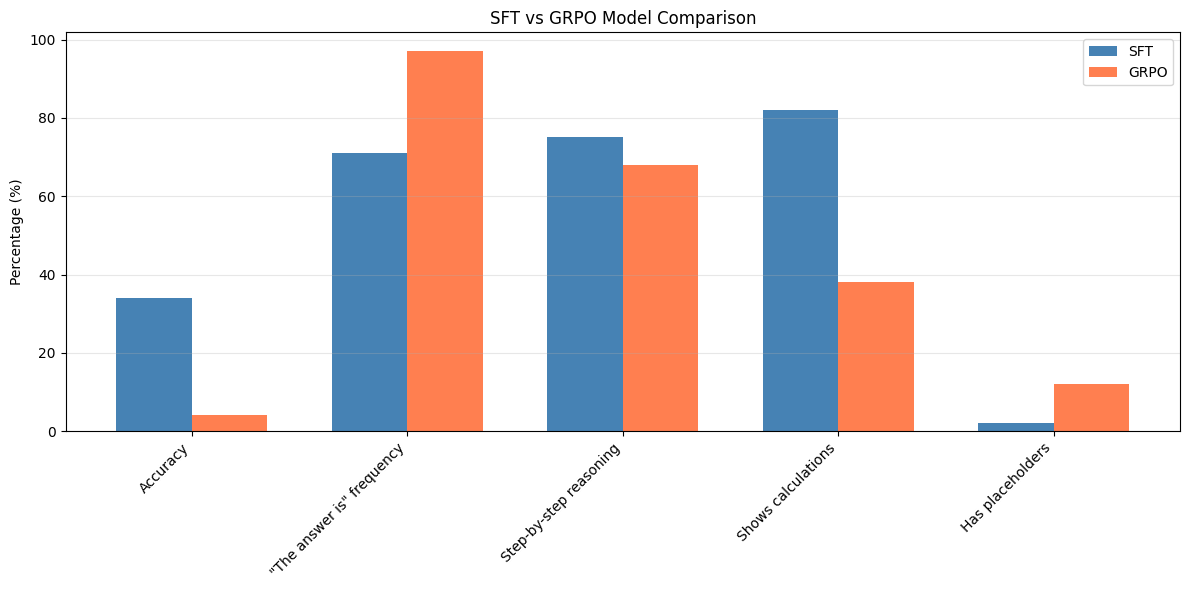


ANALYSIS COMPLETE


In [ ]:
import json
import re
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_model_outputs(results_file_path, model_name="Model"):
    """
    Comprehensive analysis of model outputs
    """
    # Load results
    with open(results_file_path, 'r') as f:
        results = json.load(f)

    stats = {
        'total_questions': len(results),
        'correct_answers': 0,
        'has_answer_phrase': 0,
        'has_boxed_answer': 0,
        'has_step_markers': 0,
        'has_calculations': 0,
        'has_placeholders': 0,
        'has_brackets_in_answer': 0,
        'response_lengths': [],
        'answer_formats': defaultdict(int),
        'common_patterns': defaultdict(int)
    }

    placeholder_keywords = ['[total]', '[profit]', '[answer]', '[net profit]',
                           '[savings]', '[hypothetical', '[the answer is',
                           '[total number', '[average_guess]', '[years']

    for item in results:
        response = item.get('model_result', '')
        final_answer = item.get('final_answer', '')
        is_correct = item.get('is_correct', False)

        # Accuracy
        if is_correct:
            stats['correct_answers'] += 1

        # Check for "the answer is" phrase
        if 'the answer is' in response.lower():
            stats['has_answer_phrase'] += 1

        # Check for boxed answers (LaTeX)
        if '\\boxed{' in response or '\\boxed' in response:
            stats['has_boxed_answer'] += 1

        # Check for step markers
        step_patterns = [
            r'\d+\.',  # "1.", "2.", etc.
            r'Step \d+',  # "Step 1", "Step 2"
            r'\(\d+\)',  # "(1)", "(2)"
            r'First,|Second,|Third,|Finally,'
        ]
        if any(re.search(pattern, response, re.IGNORECASE) for pattern in step_patterns):
            stats['has_step_markers'] += 1

        # Check for mathematical calculations shown
        calc_patterns = [
            r'\d+\s*[\+\-\*\/×÷]\s*\d+\s*=\s*\d+',  # "5 + 3 = 8"
            r'\$\d+',  # Dollar amounts
            r'\d+%',  # Percentages
        ]
        if any(re.search(pattern, response) for pattern in calc_patterns):
            stats['has_calculations'] += 1

        # Check for placeholder text
        if any(placeholder in response.lower() for placeholder in placeholder_keywords):
            stats['has_placeholders'] += 1

        # Check for brackets in final answer
        if '[' in final_answer or ']' in final_answer:
            stats['has_brackets_in_answer'] += 1

        # Response length
        word_count = len(response.split())
        stats['response_lengths'].append(word_count)

        # Categorize answer format
        if '\\boxed{' in final_answer:
            stats['answer_formats']['boxed'] += 1
        elif '[' in final_answer:
            stats['answer_formats']['brackets'] += 1
        elif final_answer.replace('.', '').replace(',', '').replace('-', '').isdigit():
            stats['answer_formats']['plain_number'] += 1
        elif '$' in final_answer:
            stats['answer_formats']['currency'] += 1
        else:
            stats['answer_formats']['other'] += 1

        # Common error patterns
        if 'therefore, the answer is' in response.lower():
            stats['common_patterns']['concludes_properly'] += 1
        if len(response.strip()) < 50:
            stats['common_patterns']['very_short'] += 1
        if len(response.split('\n')) > 10:
            stats['common_patterns']['multi_line'] += 1

    # Calculate averages and percentages
    total = stats['total_questions']
    avg_length = sum(stats['response_lengths']) / total if total > 0 else 0

    metrics = {
        'Model': model_name,
        'Total Questions': total,
        'Accuracy (%)': (stats['correct_answers'] / total * 100) if total > 0 else 0,
        '"The answer is" frequency (%)': (stats['has_answer_phrase'] / total * 100) if total > 0 else 0,
        'Boxed answers (%)': (stats['has_boxed_answer'] / total * 100) if total > 0 else 0,
        'Step-by-step reasoning (%)': (stats['has_step_markers'] / total * 100) if total > 0 else 0,
        'Shows calculations (%)': (stats['has_calculations'] / total * 100) if total > 0 else 0,
        'Has placeholders (%)': (stats['has_placeholders'] / total * 100) if total > 0 else 0,
        'Brackets in answer (%)': (stats['has_brackets_in_answer'] / total * 100) if total > 0 else 0,
        'Average response length (words)': avg_length,
    }

    return metrics, stats

def compare_models(sft_file, grpo_file):
    """
    Compare SFT and GRPO models side by side
    """
    print("="*80)
    print("AUTOMATED MODEL COMPARISON: SFT vs GRPO")
    print("="*80)

    # Analyze both models
    sft_metrics, sft_stats = analyze_model_outputs(sft_file, "SFT")
    grpo_metrics, grpo_stats = analyze_model_outputs(grpo_file, "GRPO")

    # Print comparison table
    print(f"\n{'Metric':<40} {'SFT':<15} {'GRPO':<15} {'Change':<15}")
    print("-"*85)

    for key in sft_metrics.keys():
        if key == 'Model':
            continue

        sft_val = sft_metrics[key]
        grpo_val = grpo_metrics[key]

        if isinstance(sft_val, float):
            change = grpo_val - sft_val
            if 'words' in key.lower():
                print(f"{key:<40} {sft_val:>6.1f} {grpo_val:>20.1f} {change:>13.1f}")
            else:
                print(f"{key:<40} {sft_val:>6.2f}% {grpo_val:>18.2f}% {change:>11.2f}%")
        else:
            print(f"{key:<40} {sft_val:>6} {grpo_val:>20} {grpo_val - sft_val:>15}")

    # Answer format breakdown
    print("\n" + "="*80)
    print("ANSWER FORMAT DISTRIBUTION")
    print("="*80)
    print(f"{'Format':<30} {'SFT Count':<15} {'GRPO Count':<15}")
    print("-"*60)

    all_formats = set(list(sft_stats['answer_formats'].keys()) +
                     list(grpo_stats['answer_formats'].keys()))

    for fmt in sorted(all_formats):
        sft_count = sft_stats['answer_formats'].get(fmt, 0)
        grpo_count = grpo_stats['answer_formats'].get(fmt, 0)
        print(f"{fmt:<30} {sft_count:<15} {grpo_count:<15}")

    # Sample comparisons
    print("\n" + "="*80)
    print("SAMPLE OUTPUT COMPARISON")
    print("="*80)

    with open(sft_file, 'r') as f:
        sft_results = json.load(f)
    with open(grpo_file, 'r') as f:
        grpo_results = json.load(f)

    # Show first 3 examples
    for i in range(min(3, len(sft_results))):
        print(f"\n{'='*80}")
        print(f"EXAMPLE {i+1}: {sft_results[i]['question'][:80]}...")
        print(f"{'='*80}")
        print(f"\nCorrect Answer: {sft_results[i]['correct_answer']}")

        print(f"\n--- SFT Model ---")
        print(f"Final Answer: {sft_results[i]['final_answer']}")
        print(f"Correct: {sft_results[i]['is_correct']}")
        print(f"Response preview: {sft_results[i]['model_result'][:200]}...")

        print(f"\n--- GRPO Model ---")
        print(f"Final Answer: {grpo_results[i]['final_answer']}")
        print(f"Correct: {grpo_results[i]['is_correct']}")
        print(f"Response preview: {grpo_results[i]['model_result'][:200]}...")

    return sft_metrics, grpo_metrics, sft_stats, grpo_stats

def plot_comparison(sft_metrics, grpo_metrics):
    """
    Create visualization comparing metrics
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Metrics to plot
    metrics_to_plot = [
        'Accuracy (%)',
        '"The answer is" frequency (%)',
        'Step-by-step reasoning (%)',
        'Shows calculations (%)',
        'Has placeholders (%)',
    ]

    sft_values = [sft_metrics[m] for m in metrics_to_plot]
    grpo_values = [grpo_metrics[m] for m in metrics_to_plot]

    x = np.arange(len(metrics_to_plot))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, sft_values, width, label='SFT', color='steelblue')
    bars2 = ax.bar(x + width/2, grpo_values, width, label='GRPO', color='coral')

    ax.set_ylabel('Percentage (%)')
    ax.set_title('SFT vs GRPO Model Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (%)', '') for m in metrics_to_plot], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('sft_vs_grpo_comparison.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved as 'sft_vs_grpo_comparison.png'")
    plt.show()

# Run the analysis
if __name__ == "__main__":
    # File paths - update these to your actual file paths
    sft_results_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-sft-eval/results.json'
    grpo_results_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo/results.json'

    # Run comparison
    sft_metrics, grpo_metrics, sft_stats, grpo_stats = compare_models(
        sft_results_file,
        grpo_results_file
    )

    # Create visualization
    plot_comparison(sft_metrics, grpo_metrics)

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)

In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 26.8 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [ ]:
WANDB_API_KEY = "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"

In [ ]:
!python grpo/main.py \
  --model_signature Qwen/Qwen2.5-0.5B-Instruct \
  --adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
  --output_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo \
  --wandb_token {WANDB_API_KEY}

Logging into WandB with provided token 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...
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s2808241 (s2808241-university-of-ediburgh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
Loading Base Model: Qwen/Qwen2.5-0.5B-Instruct...
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 290/290 [00:00<00:00, 320.49it/s, Materializing param=model.norm.weight]
Loading and Merging SFT Adapter from ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft...
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn

In [ ]:
!pip install -r requirements.txt


**Qurestion 4 Re Run Again**

In [ ]:
import shutil
shutil.rmtree('./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo', ignore_errors=True)
shutil.rmtree('./outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo', ignore_errors=True)
print("Old Q4 files cleared.")

Old Q4 files cleared.


In [ ]:
WANDB_API_KEY = "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"

!python grpo/main.py \
  --model_signature Qwen/Qwen2.5-0.5B-Instruct \
  --adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
  --output_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo \
  --wandb_token {WANDB_API_KEY}

2026-02-25 14:31:17.253590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772029877.274888    7155 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772029877.282567    7155 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772029877.301679    7155 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772029877.301703    7155 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772029877.301707    7155 computation_placer.cc:177] computation placer alr

In [ ]:
!python evaluation/main.py \
  --model_signature Qwen/Qwen2.5-0.5B-Instruct \
  --sft_adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
  --grpo_adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo \
  --output_path ./outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo

2026-02-25 15:28:56.646399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772033336.666862   21681 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772033336.673618   21681 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772033336.691928   21681 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772033336.691951   21681 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772033336.691954   21681 computation_placer.cc:177] computation placer alr

SFT vs GRPO Comparison


AUTOMATED MODEL COMPARISON: SFT vs GRPO

Metric                                   SFT             GRPO            Change         
-------------------------------------------------------------------------------------
Total Questions                             100                  100               0
Accuracy (%)                              34.00%              32.00%       -2.00%
"The answer is" frequency (%)             71.00%              96.00%       25.00%
Boxed answers (%)                         19.00%               2.00%      -17.00%
Step-by-step reasoning (%)                75.00%              68.00%       -7.00%
Shows calculations (%)                    82.00%              92.00%       10.00%
Has placeholders (%)                       2.00%               0.00%       -2.00%
Brackets in answer (%)                     8.00%               3.00%       -5.00%
Average response length (words)           102.0                 68.4         -33.6

ANSWER FORMAT DISTRIBUTION
Format        

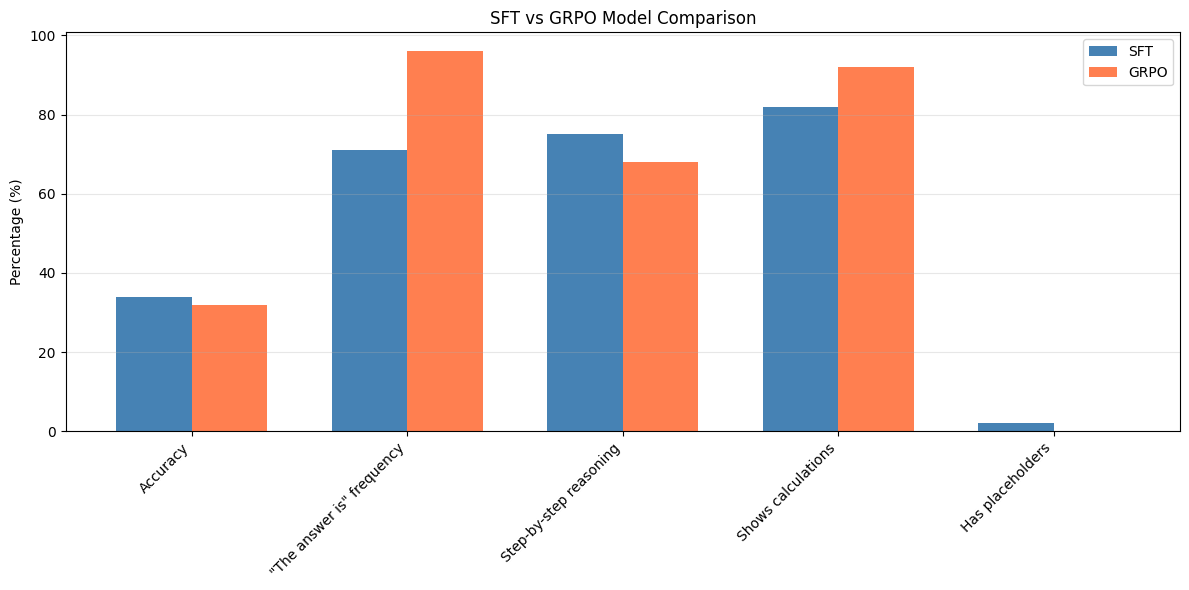


ANALYSIS COMPLETE


In [ ]:
import json
import re
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_model_outputs(results_file_path, model_name="Model"):
    """
    Comprehensive analysis of model outputs
    """
    # Load results
    with open(results_file_path, 'r') as f:
        results = json.load(f)

    stats = {
        'total_questions': len(results),
        'correct_answers': 0,
        'has_answer_phrase': 0,
        'has_boxed_answer': 0,
        'has_step_markers': 0,
        'has_calculations': 0,
        'has_placeholders': 0,
        'has_brackets_in_answer': 0,
        'response_lengths': [],
        'answer_formats': defaultdict(int),
        'common_patterns': defaultdict(int)
    }

    placeholder_keywords = ['[total]', '[profit]', '[answer]', '[net profit]',
                           '[savings]', '[hypothetical', '[the answer is',
                           '[total number', '[average_guess]', '[years']

    for item in results:
        response = item.get('model_result', '')
        final_answer = item.get('final_answer', '')
        is_correct = item.get('is_correct', False)

        # Accuracy
        if is_correct:
            stats['correct_answers'] += 1

        # Check for "the answer is" phrase
        if 'the answer is' in response.lower():
            stats['has_answer_phrase'] += 1

        # Check for boxed answers (LaTeX)
        if '\\boxed{' in response or '\\boxed' in response:
            stats['has_boxed_answer'] += 1

        # Check for step markers
        step_patterns = [
            r'\d+\.',  # "1.", "2.", etc.
            r'Step \d+',  # "Step 1", "Step 2"
            r'\(\d+\)',  # "(1)", "(2)"
            r'First,|Second,|Third,|Finally,'
        ]
        if any(re.search(pattern, response, re.IGNORECASE) for pattern in step_patterns):
            stats['has_step_markers'] += 1

        # Check for mathematical calculations shown
        calc_patterns = [
            r'\d+\s*[\+\-\*\/×÷]\s*\d+\s*=\s*\d+',  # "5 + 3 = 8"
            r'\$\d+',  # Dollar amounts
            r'\d+%',  # Percentages
        ]
        if any(re.search(pattern, response) for pattern in calc_patterns):
            stats['has_calculations'] += 1

        # Check for placeholder text
        if any(placeholder in response.lower() for placeholder in placeholder_keywords):
            stats['has_placeholders'] += 1

        # Check for brackets in final answer
        if '[' in final_answer or ']' in final_answer:
            stats['has_brackets_in_answer'] += 1

        # Response length
        word_count = len(response.split())
        stats['response_lengths'].append(word_count)

        # Categorize answer format
        if '\\boxed{' in final_answer:
            stats['answer_formats']['boxed'] += 1
        elif '[' in final_answer:
            stats['answer_formats']['brackets'] += 1
        elif final_answer.replace('.', '').replace(',', '').replace('-', '').isdigit():
            stats['answer_formats']['plain_number'] += 1
        elif '$' in final_answer:
            stats['answer_formats']['currency'] += 1
        else:
            stats['answer_formats']['other'] += 1

        # Common error patterns
        if 'therefore, the answer is' in response.lower():
            stats['common_patterns']['concludes_properly'] += 1
        if len(response.strip()) < 50:
            stats['common_patterns']['very_short'] += 1
        if len(response.split('\n')) > 10:
            stats['common_patterns']['multi_line'] += 1

    # Calculate averages and percentages
    total = stats['total_questions']
    avg_length = sum(stats['response_lengths']) / total if total > 0 else 0

    metrics = {
        'Model': model_name,
        'Total Questions': total,
        'Accuracy (%)': (stats['correct_answers'] / total * 100) if total > 0 else 0,
        '"The answer is" frequency (%)': (stats['has_answer_phrase'] / total * 100) if total > 0 else 0,
        'Boxed answers (%)': (stats['has_boxed_answer'] / total * 100) if total > 0 else 0,
        'Step-by-step reasoning (%)': (stats['has_step_markers'] / total * 100) if total > 0 else 0,
        'Shows calculations (%)': (stats['has_calculations'] / total * 100) if total > 0 else 0,
        'Has placeholders (%)': (stats['has_placeholders'] / total * 100) if total > 0 else 0,
        'Brackets in answer (%)': (stats['has_brackets_in_answer'] / total * 100) if total > 0 else 0,
        'Average response length (words)': avg_length,
    }

    return metrics, stats

def compare_models(sft_file, grpo_file):
    """
    Compare SFT and GRPO models side by side
    """
    print("="*80)
    print("AUTOMATED MODEL COMPARISON: SFT vs GRPO")
    print("="*80)

    # Analyze both models
    sft_metrics, sft_stats = analyze_model_outputs(sft_file, "SFT")
    grpo_metrics, grpo_stats = analyze_model_outputs(grpo_file, "GRPO")

    # Print comparison table
    print(f"\n{'Metric':<40} {'SFT':<15} {'GRPO':<15} {'Change':<15}")
    print("-"*85)

    for key in sft_metrics.keys():
        if key == 'Model':
            continue

        sft_val = sft_metrics[key]
        grpo_val = grpo_metrics[key]

        if isinstance(sft_val, float):
            change = grpo_val - sft_val
            if 'words' in key.lower():
                print(f"{key:<40} {sft_val:>6.1f} {grpo_val:>20.1f} {change:>13.1f}")
            else:
                print(f"{key:<40} {sft_val:>6.2f}% {grpo_val:>18.2f}% {change:>11.2f}%")
        else:
            print(f"{key:<40} {sft_val:>6} {grpo_val:>20} {grpo_val - sft_val:>15}")

    # Answer format breakdown
    print("\n" + "="*80)
    print("ANSWER FORMAT DISTRIBUTION")
    print("="*80)
    print(f"{'Format':<30} {'SFT Count':<15} {'GRPO Count':<15}")
    print("-"*60)

    all_formats = set(list(sft_stats['answer_formats'].keys()) +
                     list(grpo_stats['answer_formats'].keys()))

    for fmt in sorted(all_formats):
        sft_count = sft_stats['answer_formats'].get(fmt, 0)
        grpo_count = grpo_stats['answer_formats'].get(fmt, 0)
        print(f"{fmt:<30} {sft_count:<15} {grpo_count:<15}")

    # Sample comparisons
    print("\n" + "="*80)
    print("SAMPLE OUTPUT COMPARISON")
    print("="*80)

    with open(sft_file, 'r') as f:
        sft_results = json.load(f)
    with open(grpo_file, 'r') as f:
        grpo_results = json.load(f)

    # Show first 3 examples
    for i in range(min(3, len(sft_results))):
        print(f"\n{'='*80}")
        print(f"EXAMPLE {i+1}: {sft_results[i]['question'][:80]}...")
        print(f"{'='*80}")
        print(f"\nCorrect Answer: {sft_results[i]['correct_answer']}")

        print(f"\n--- SFT Model ---")
        print(f"Final Answer: {sft_results[i]['final_answer']}")
        print(f"Correct: {sft_results[i]['is_correct']}")
        print(f"Response preview: {sft_results[i]['model_result'][:200]}...")

        print(f"\n--- GRPO Model ---")
        print(f"Final Answer: {grpo_results[i]['final_answer']}")
        print(f"Correct: {grpo_results[i]['is_correct']}")
        print(f"Response preview: {grpo_results[i]['model_result'][:200]}...")

    return sft_metrics, grpo_metrics, sft_stats, grpo_stats

def plot_comparison(sft_metrics, grpo_metrics):
    """
    Create visualization comparing metrics
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Metrics to plot
    metrics_to_plot = [
        'Accuracy (%)',
        '"The answer is" frequency (%)',
        'Step-by-step reasoning (%)',
        'Shows calculations (%)',
        'Has placeholders (%)',
    ]

    sft_values = [sft_metrics[m] for m in metrics_to_plot]
    grpo_values = [grpo_metrics[m] for m in metrics_to_plot]

    x = np.arange(len(metrics_to_plot))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, sft_values, width, label='SFT', color='steelblue')
    bars2 = ax.bar(x + width/2, grpo_values, width, label='GRPO', color='coral')

    ax.set_ylabel('Percentage (%)')
    ax.set_title('SFT vs GRPO Model Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (%)', '') for m in metrics_to_plot], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('sft_vs_grpo_comparison.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved as 'sft_vs_grpo_comparison.png'")
    plt.show()

# Run the analysis
if __name__ == "__main__":
    # File paths - update these to your actual file paths
    sft_results_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-sft-eval/results.json'
    grpo_results_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo/results.json'

    # Run comparison
    sft_metrics, grpo_metrics, sft_stats, grpo_stats = compare_models(
        sft_results_file,
        grpo_results_file
    )

    # Create visualization
    plot_comparison(sft_metrics, grpo_metrics)

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

AUTOMATED MODEL COMPARISON: SFT vs GRPO (WITH TOKEN COUNTS)

Metric                                        SFT             GRPO            Change         
------------------------------------------------------------------------------------------
Total Questions                                  100                  100               0
Accuracy (%)                                   34.00%              32.00%       -2.00%
"The answer is" frequency (%)                  71.00%              96.00%       25.00%
Boxed answers (%)                              19.00%               2.00%      -17.00%
Step-by-step reasoning (%)                     75.00%              68.00%       -7.00%
Shows calculations (%)                         82.00%              92.00%       10.00%
Has placeholders (%)                            2.00%               0.00%       -2.00%
Brackets in answer (%)                          8.00%               3.00%       -5.00%
Average response length (words)                102.0   

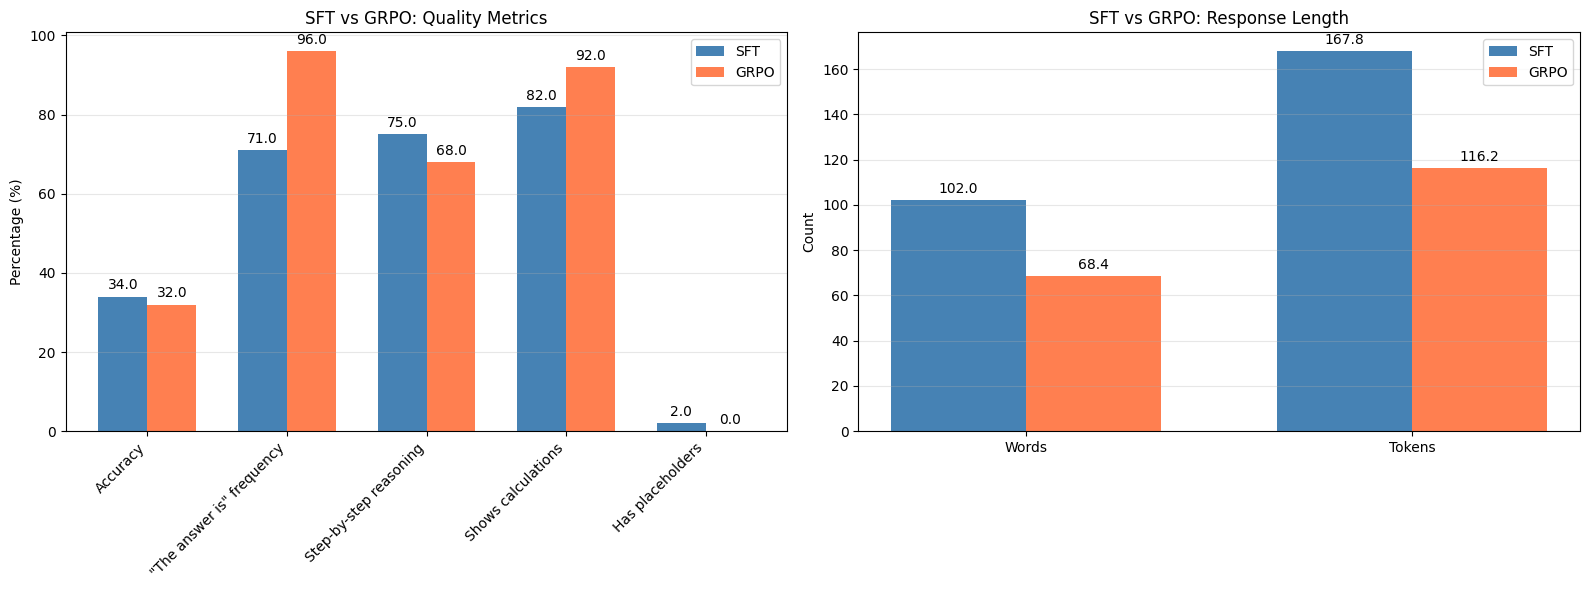


ANALYSIS COMPLETE


In [3]:
import json
import re
from collections import defaultdict
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

def analyze_model_outputs_with_tokens(results_file_path, tokenizer, model_name="Model"):
    """
    Comprehensive analysis of model outputs including token counts
    """
    # Load results
    with open(results_file_path, 'r') as f:
        results = json.load(f)

    stats = {
        'total_questions': len(results),
        'correct_answers': 0,
        'has_answer_phrase': 0,
        'has_boxed_answer': 0,
        'has_step_markers': 0,
        'has_calculations': 0,
        'has_placeholders': 0,
        'has_brackets_in_answer': 0,
        'response_word_lengths': [],
        'response_token_lengths': [],  # NEW: Token lengths
        'answer_formats': defaultdict(int),
        'common_patterns': defaultdict(int)
    }

    placeholder_keywords = ['[total]', '[profit]', '[answer]', '[net profit]',
                           '[savings]', '[hypothetical', '[the answer is',
                           '[total number', '[average_guess]', '[years']

    for item in results:
        response = item.get('model_result', '')
        final_answer = item.get('final_answer', '')
        is_correct = item.get('is_correct', False)

        # Accuracy
        if is_correct:
            stats['correct_answers'] += 1

        # Check for "the answer is" phrase
        if 'the answer is' in response.lower():
            stats['has_answer_phrase'] += 1

        # Check for boxed answers (LaTeX)
        if '\\boxed{' in response or '\\boxed' in response:
            stats['has_boxed_answer'] += 1

        # Check for step markers
        step_patterns = [
            r'\d+\.',  # "1.", "2.", etc.
            r'Step \d+',  # "Step 1", "Step 2"
            r'\(\d+\)',  # "(1)", "(2)"
            r'First,|Second,|Third,|Finally,'
        ]
        if any(re.search(pattern, response, re.IGNORECASE) for pattern in step_patterns):
            stats['has_step_markers'] += 1

        # Check for mathematical calculations shown
        calc_patterns = [
            r'\d+\s*[\+\-\*\/×÷]\s*\d+\s*=\s*\d+',  # "5 + 3 = 8"
            r'\$\d+',  # Dollar amounts
            r'\d+%',  # Percentages
        ]
        if any(re.search(pattern, response) for pattern in calc_patterns):
            stats['has_calculations'] += 1

        # Check for placeholder text
        if any(placeholder in response.lower() for placeholder in placeholder_keywords):
            stats['has_placeholders'] += 1

        # Check for brackets in final answer
        if '[' in final_answer or ']' in final_answer:
            stats['has_brackets_in_answer'] += 1

        # Word count
        word_count = len(response.split())
        stats['response_word_lengths'].append(word_count)

        # TOKEN COUNT (NEW!)
        token_count = len(tokenizer.encode(response, add_special_tokens=False))
        stats['response_token_lengths'].append(token_count)

        # Categorize answer format
        if '\\boxed{' in final_answer:
            stats['answer_formats']['boxed'] += 1
        elif '[' in final_answer:
            stats['answer_formats']['brackets'] += 1
        elif final_answer.replace('.', '').replace(',', '').replace('-', '').isdigit():
            stats['answer_formats']['plain_number'] += 1
        elif '$' in final_answer:
            stats['answer_formats']['currency'] += 1
        else:
            stats['answer_formats']['other'] += 1

        # Common error patterns
        if 'therefore, the answer is' in response.lower():
            stats['common_patterns']['concludes_properly'] += 1
        if len(response.strip()) < 50:
            stats['common_patterns']['very_short'] += 1
        if len(response.split('\n')) > 10:
            stats['common_patterns']['multi_line'] += 1

    # Calculate averages and percentages
    total = stats['total_questions']
    avg_word_length = sum(stats['response_word_lengths']) / total if total > 0 else 0
    avg_token_length = sum(stats['response_token_lengths']) / total if total > 0 else 0

    metrics = {
        'Model': model_name,
        'Total Questions': total,
        'Accuracy (%)': (stats['correct_answers'] / total * 100) if total > 0 else 0,
        '"The answer is" frequency (%)': (stats['has_answer_phrase'] / total * 100) if total > 0 else 0,
        'Boxed answers (%)': (stats['has_boxed_answer'] / total * 100) if total > 0 else 0,
        'Step-by-step reasoning (%)': (stats['has_step_markers'] / total * 100) if total > 0 else 0,
        'Shows calculations (%)': (stats['has_calculations'] / total * 100) if total > 0 else 0,
        'Has placeholders (%)': (stats['has_placeholders'] / total * 100) if total > 0 else 0,
        'Brackets in answer (%)': (stats['has_brackets_in_answer'] / total * 100) if total > 0 else 0,
        'Average response length (words)': avg_word_length,
        'Average response length (tokens)': avg_token_length,  # NEW!
    }

    return metrics, stats


def compare_models_with_tokens(sft_file, grpo_file, tokenizer):
    """
    Compare SFT and GRPO models including token counts
    """
    print("="*80)
    print("AUTOMATED MODEL COMPARISON: SFT vs GRPO (WITH TOKEN COUNTS)")
    print("="*80)

    # Analyze both models
    sft_metrics, sft_stats = analyze_model_outputs_with_tokens(sft_file, tokenizer, "SFT")
    grpo_metrics, grpo_stats = analyze_model_outputs_with_tokens(grpo_file, tokenizer, "GRPO")

    # Print comparison table
    print(f"\n{'Metric':<45} {'SFT':<15} {'GRPO':<15} {'Change':<15}")
    print("-"*90)

    for key in sft_metrics.keys():
        if key == 'Model':
            continue

        sft_val = sft_metrics[key]
        grpo_val = grpo_metrics[key]

        if isinstance(sft_val, float):
            change = grpo_val - sft_val
            if 'words' in key.lower() or 'tokens' in key.lower():
                print(f"{key:<45} {sft_val:>6.1f} {grpo_val:>20.1f} {change:>13.1f}")
            else:
                print(f"{key:<45} {sft_val:>6.2f}% {grpo_val:>18.2f}% {change:>11.2f}%")
        else:
            print(f"{key:<45} {sft_val:>6} {grpo_val:>20} {grpo_val - sft_val:>15}")

    # Token length distribution
    print("\n" + "="*80)
    print("RESPONSE LENGTH STATISTICS")
    print("="*80)

    import numpy as np

    print(f"\n{'Metric':<40} {'SFT':<20} {'GRPO':<20}")
    print("-"*80)

    # Words
    print(f"{'Average words':<40} {np.mean(sft_stats['response_word_lengths']):.1f} {np.mean(grpo_stats['response_word_lengths']):.1f}")
    print(f"{'Median words':<40} {np.median(sft_stats['response_word_lengths']):.1f} {np.median(grpo_stats['response_word_lengths']):.1f}")
    print(f"{'Min words':<40} {np.min(sft_stats['response_word_lengths']):.0f} {np.min(grpo_stats['response_word_lengths']):.0f}")
    print(f"{'Max words':<40} {np.max(sft_stats['response_word_lengths']):.0f} {np.max(grpo_stats['response_word_lengths']):.0f}")

    # Tokens
    print(f"\n{'Average tokens':<40} {np.mean(sft_stats['response_token_lengths']):.1f} {np.mean(grpo_stats['response_token_lengths']):.1f}")
    print(f"{'Median tokens':<40} {np.median(sft_stats['response_token_lengths']):.1f} {np.median(grpo_stats['response_token_lengths']):.1f}")
    print(f"{'Min tokens':<40} {np.min(sft_stats['response_token_lengths']):.0f} {np.min(grpo_stats['response_token_lengths']):.0f}")
    print(f"{'Max tokens':<40} {np.max(sft_stats['response_token_lengths']):.0f} {np.max(grpo_stats['response_token_lengths']):.0f}")

    # Answer format breakdown
    print("\n" + "="*80)
    print("ANSWER FORMAT DISTRIBUTION")
    print("="*80)
    print(f"{'Format':<30} {'SFT Count':<15} {'GRPO Count':<15}")
    print("-"*60)

    all_formats = set(list(sft_stats['answer_formats'].keys()) +
                     list(grpo_stats['answer_formats'].keys()))

    for fmt in sorted(all_formats):
        sft_count = sft_stats['answer_formats'].get(fmt, 0)
        grpo_count = grpo_stats['answer_formats'].get(fmt, 0)
        print(f"{fmt:<30} {sft_count:<15} {grpo_count:<15}")

    # Sample comparisons with token counts
    print("\n" + "="*80)
    print("SAMPLE OUTPUT COMPARISON (WITH TOKEN COUNTS)")
    print("="*80)

    with open(sft_file, 'r') as f:
        sft_results = json.load(f)
    with open(grpo_file, 'r') as f:
        grpo_results = json.load(f)

    # Show first 3 examples
    for i in range(min(3, len(sft_results))):
        print(f"\n{'='*80}")
        print(f"EXAMPLE {i+1}: {sft_results[i]['question'][:80]}...")
        print(f"{'='*80}")
        print(f"\nCorrect Answer: {sft_results[i]['correct_answer']}")

        sft_response = sft_results[i]['model_result']
        grpo_response = grpo_results[i]['model_result']

        sft_tokens = len(tokenizer.encode(sft_response, add_special_tokens=False))
        grpo_tokens = len(tokenizer.encode(grpo_response, add_special_tokens=False))

        print(f"\n--- SFT Model ---")
        print(f"Final Answer: {sft_results[i]['final_answer']}")
        print(f"Correct: {sft_results[i]['is_correct']}")
        print(f"Length: {len(sft_response.split())} words, {sft_tokens} tokens")
        print(f"Response preview: {sft_response[:200]}...")

        print(f"\n--- GRPO Model ---")
        print(f"Final Answer: {grpo_results[i]['final_answer']}")
        print(f"Correct: {grpo_results[i]['is_correct']}")
        print(f"Length: {len(grpo_response.split())} words, {grpo_tokens} tokens")
        print(f"Response preview: {grpo_response[:200]}...")

    return sft_metrics, grpo_metrics, sft_stats, grpo_stats


def plot_comparison_with_tokens(sft_metrics, grpo_metrics):
    """
    Create visualization comparing metrics including token lengths
    """
    import numpy as np

    # Metrics to plot
    metrics_to_plot = [
        'Accuracy (%)',
        '"The answer is" frequency (%)',
        'Step-by-step reasoning (%)',
        'Shows calculations (%)',
        'Has placeholders (%)',
    ]

    sft_values = [sft_metrics[m] for m in metrics_to_plot]
    grpo_values = [grpo_metrics[m] for m in metrics_to_plot]

    x = np.arange(len(metrics_to_plot))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Percentage metrics
    bars1 = ax1.bar(x - width/2, sft_values, width, label='SFT', color='steelblue')
    bars2 = ax1.bar(x + width/2, grpo_values, width, label='GRPO', color='coral')

    ax1.set_ylabel('Percentage (%)')
    ax1.set_title('SFT vs GRPO: Quality Metrics')
    ax1.set_xticks(x)
    ax1.set_xticklabels([m.replace(' (%)', '') for m in metrics_to_plot], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Plot 2: Length comparison (words vs tokens)
    length_metrics = ['Average response length (words)', 'Average response length (tokens)']
    sft_lengths = [sft_metrics[m] for m in length_metrics]
    grpo_lengths = [grpo_metrics[m] for m in length_metrics]

    x2 = np.arange(len(length_metrics))
    bars3 = ax2.bar(x2 - width/2, sft_lengths, width, label='SFT', color='steelblue')
    bars4 = ax2.bar(x2 + width/2, grpo_lengths, width, label='GRPO', color='coral')

    ax2.set_ylabel('Count')
    ax2.set_title('SFT vs GRPO: Response Length')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(['Words', 'Tokens'])
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for ax in [ax1, ax2]:
        for bars in ax.containers:
            ax.bar_label(bars, fmt='%.1f', padding=3)

    plt.tight_layout()
    plt.savefig('sft_vs_grpo_with_tokens.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved as 'sft_vs_grpo_with_tokens.png'")
    plt.show()


# Run the analysis
if __name__ == "__main__":
    from transformers import AutoTokenizer

    # Load tokenizer
    print("Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct", trust_remote_code=True)

    # File paths - update these to your actual file paths
    sft_results_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-sft-eval/results.json'
    grpo_results_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo/results.json'

    # Run comparison with token counts
    sft_metrics, grpo_metrics, sft_stats, grpo_stats = compare_models_with_tokens(
        sft_results_file,
        grpo_results_file,
        tokenizer
    )

    # Create visualization
    plot_comparison_with_tokens(sft_metrics, grpo_metrics)

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)

In [4]:
import json

def print_full_examples_for_report(sft_file, grpo_file, num_examples=2):
    """
    Print complete examples showing full question and responses
    for inclusion in report
    """
    # Load results
    with open(sft_file, 'r') as f:
        sft_results = json.load(f)
    with open(grpo_file, 'r') as f:
        grpo_results = json.load(f)

    print("="*100)
    print("COMPLETE EXAMPLES FOR REPORT")
    print("="*100)

    for i in range(min(num_examples, len(sft_results))):
        print(f"\n{'='*100}")
        print(f"EXAMPLE {i+1}")
        print(f"{'='*100}\n")

        # Question
        question = sft_results[i]['question']
        correct_answer = sft_results[i]['correct_answer']

        print(f"QUESTION:")
        print(f"{question}\n")

        print(f"CORRECT ANSWER: {correct_answer}\n")

        # SFT Response
        print(f"{'-'*100}")
        print(f"SFT MODEL RESPONSE:")
        print(f"{'-'*100}")
        sft_response = sft_results[i]['model_result']
        sft_final = sft_results[i]['final_answer']
        sft_correct = sft_results[i]['is_correct']

        print(f"{sft_response}")
        print(f"\nExtracted Answer: {sft_final}")
        print(f"Correct: {'✓' if sft_correct else '✗'}")

        # GRPO Response
        print(f"\n{'-'*100}")
        print(f"GRPO MODEL RESPONSE:")
        print(f"{'-'*100}")
        grpo_response = grpo_results[i]['model_result']
        grpo_final = grpo_results[i]['final_answer']
        grpo_correct = grpo_results[i]['is_correct']

        print(f"{grpo_response}")
        print(f"\nExtracted Answer: {grpo_final}")
        print(f"Correct: {'✓' if grpo_correct else '✗'}")

        print(f"\n{'='*100}\n")


def print_latex_formatted_examples(sft_file, grpo_file, num_examples=2):
    """
    Print examples in a format ready for LaTeX/report
    """
    # Load results
    with open(sft_file, 'r') as f:
        sft_results = json.load(f)
    with open(grpo_file, 'r') as f:
        grpo_results = json.load(f)

    print("\n" + "="*100)
    print("LATEX-FORMATTED EXAMPLES")
    print("="*100 + "\n")

    for i in range(min(num_examples, len(sft_results))):
        question = sft_results[i]['question']
        correct_answer = sft_results[i]['correct_answer']
        sft_response = sft_results[i]['model_result']
        grpo_response = grpo_results[i]['model_result']

        print(f"\\textbf{{Example {i+1}:}}\n")
        print(f"\\textit{{Question:}} {question}\n")
        print(f"\\textit{{Correct Answer:}} {correct_answer}\n")

        print(f"\\textbf{{SFT Response:}}")
        print(f"\\begin{{quote}}")
        print(f"{sft_response}")
        print(f"\\end{{quote}}\n")

        print(f"\\textbf{{GRPO Response:}}")
        print(f"\\begin{{quote}}")
        print(f"{grpo_response}")
        print(f"\\end{{quote}}\n")

        print("-"*100 + "\n")


def find_interesting_examples(sft_file, grpo_file):
    """
    Find particularly interesting examples showing the difference
    """
    with open(sft_file, 'r') as f:
        sft_results = json.load(f)
    with open(grpo_file, 'r') as f:
        grpo_results = json.load(f)

    print("\n" + "="*100)
    print("FINDING INTERESTING EXAMPLES")
    print("="*100 + "\n")

    # Category 1: SFT correct, GRPO wrong
    print("Category 1: SFT CORRECT → GRPO WRONG (showing degradation)")
    print("-"*100)

    sft_correct_grpo_wrong = []
    for i, (sft, grpo) in enumerate(zip(sft_results, grpo_results)):
        if sft['is_correct'] and not grpo['is_correct']:
            sft_correct_grpo_wrong.append((i, sft, grpo))

    if sft_correct_grpo_wrong:
        idx, sft, grpo = sft_correct_grpo_wrong[0]  # First example
        print(f"\nExample index: {idx}")
        print(f"Question: {sft['question']}")
        print(f"Correct answer: {sft['correct_answer']}")
        print(f"\nSFT: {sft['final_answer']} ✓")
        print(f"GRPO: {grpo['final_answer']} ✗")
        print(f"\nSFT response length: {len(sft['model_result'].split())} words")
        print(f"GRPO response length: {len(grpo['model_result'].split())} words")

    # Category 2: Both wrong, but GRPO much shorter
    print(f"\n\nCategory 2: BOTH WRONG, but GRPO shows shortcut behavior")
    print("-"*100)

    both_wrong_short = []
    for i, (sft, grpo) in enumerate(zip(sft_results, grpo_results)):
        if not sft['is_correct'] and not grpo['is_correct']:
            sft_len = len(sft['model_result'].split())
            grpo_len = len(grpo['model_result'].split())
            if sft_len > 50 and grpo_len < 30:  # SFT detailed, GRPO short
                both_wrong_short.append((i, sft, grpo, sft_len, grpo_len))

    if both_wrong_short:
        idx, sft, grpo, sft_len, grpo_len = both_wrong_short[0]
        print(f"\nExample index: {idx}")
        print(f"Question: {sft['question']}")
        print(f"\nSFT ({sft_len} words): Attempted detailed reasoning")
        print(f"GRPO ({grpo_len} words): Short, superficial response")

    # Category 3: GRPO has placeholder patterns
    print(f"\n\nCategory 3: Examples showing format optimization")
    print("-"*100)

    format_examples = []
    for i, grpo in enumerate(grpo_results):
        if "the answer is" in grpo['model_result'].lower():
            format_examples.append((i, grpo))

    if format_examples:
        idx, grpo = format_examples[0]
        print(f"\nExample showing format compliance:")
        print(f"Response: {grpo['model_result'][:200]}...")
        print(f"Has 'the answer is': ✓")

    print("\n" + "="*100)
    print(f"Found {len(sft_correct_grpo_wrong)} examples where SFT correct but GRPO wrong")
    print(f"Found {len(both_wrong_short)} examples where both wrong but GRPO much shorter")
    print("="*100 + "\n")

    return sft_correct_grpo_wrong, both_wrong_short


# Main execution
if __name__ == "__main__":
    # Update these paths
    sft_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-sft-eval/results.json'
    grpo_file = './outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo/results.json'

    # Print 2 complete examples
    print_full_examples_for_report(sft_file, grpo_file, num_examples=2)

    # Also find interesting examples
    sft_correct_grpo_wrong, both_wrong_short = find_interesting_examples(sft_file, grpo_file)

    # Print one particularly interesting example in detail
    if sft_correct_grpo_wrong:
        print("\n" + "="*100)
        print("DETAILED EXAMPLE: SFT CORRECT → GRPO WRONG")
        print("="*100 + "\n")

        idx, sft, grpo = sft_correct_grpo_wrong[0]

        print(f"Question: {sft['question']}\n")
        print(f"Correct Answer: {sft['correct_answer']}\n")

        print("-"*100)
        print("SFT MODEL (CORRECT):")
        print("-"*100)
        print(f"{sft['model_result']}\n")
        print(f"Final Answer: {sft['final_answer']} ✓")
        print(f"Length: {len(sft['model_result'].split())} words")

        print(f"\n{'-'*100}")
        print("GRPO MODEL (WRONG):")
        print("-"*100)
        print(f"{grpo['model_result']}\n")
        print(f"Final Answer: {grpo['final_answer']} ✗")
        print(f"Length: {len(grpo['model_result'].split())} words")

        print("\n" + "="*100)

COMPLETE EXAMPLES FOR REPORT

EXAMPLE 1

QUESTION:
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

CORRECT ANSWER: 18

----------------------------------------------------------------------------------------------------
SFT MODEL RESPONSE:
----------------------------------------------------------------------------------------------------
To determine how much Janet makes every day from selling the eggs, we need to follow these steps:

1. Calculate the total number of eggs laid by the ducks each day.
2. Subtract the number of eggs eaten by Janet from the total number of eggs to find out how many are sold.
3. Determine how many eggs are sold at the farmers' market (which is given as $2 per egg).
4. Calculate the total earnings from selling the eggs.

First,

Ques 5 Method 1

In [ ]:
WANDB_API_KEY = "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"

# GRPO training — saves to NEW folder
!python grpo/main.py \
  --model_signature Qwen/Qwen2.5-0.5B-Instruct \
  --adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
  --output_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo_q5 \
  --wandb_token {WANDB_API_KEY}

2026-02-25 15:55:29.284436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772034929.335943   28416 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772034929.359545   28416 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772034929.416236   28416 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772034929.416279   28416 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772034929.416288   28416 computation_placer.cc:177] computation placer alr

In [ ]:
!python evaluation/main.py \
  --model_signature Qwen/Qwen2.5-0.5B-Instruct \
  --sft_adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
  --grpo_adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo_q5 \
  --output_path ./outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo-q5

2026-02-25 17:09:12.634807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772039352.656299   48050 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772039352.663225   48050 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772039352.681535   48050 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772039352.681562   48050 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772039352.681565   48050 computation_placer.cc:177] computation placer alr

Ques 5 Method 2

In [ ]:
WANDB_API_KEY = "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"

# GRPO training — saves to NEW folder
!python grpo/main.py \
  --model_signature Qwen/Qwen2.5-0.5B-Instruct \
  --adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
  --output_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo_q5 \
  --wandb_token {WANDB_API_KEY}

2026-02-25 17:30:51.511770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772040651.533385   53720 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772040651.540517   53720 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772040651.558828   53720 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772040651.558861   53720 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772040651.558868   53720 computation_placer.cc:177] computation placer alr

In [ ]:
!python evaluation/main.py \
  --model_signature Qwen/Qwen2.5-0.5B-Instruct \
  --sft_adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft \
  --grpo_adapter_path ./checkpoints/Qwen/Qwen2.5-0.5B-Instruct-sft_grpo_q5 \
  --output_path ./outputs/Qwen/Qwen2.5-0.5B-Instruct-grpo-q5

2026-02-25 18:34:31.119403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772044471.141887   69706 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772044471.149344   69706 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772044471.169908   69706 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772044471.169939   69706 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772044471.169943   69706 computation_placer.cc:177] computation placer alr